In [9]:
## aart_func is a file with the functions for the image generation
from aart_func import *
## params have all the important params of the simulation
from params import *
plt.rcParams['text.usetex'] = True

In [11]:
# local paths for loading data and downloading images
path_lensingband17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5"
path_lensingband60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5"

path_raytracing17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5"
path_raytracing60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5"

path_images = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes"

In [13]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
mask0=h5f['mask0'][:]
N0=int(h5f["N0"][0])
lim0=int(h5f["lim0"][0])

supergrid1=h5f['grid1'][:]
mask1=h5f['mask1'][:]
N1=int(h5f["N1"][0])
lim1=int(h5f["lim1"][0])

supergrid2=h5f['grid2'][:]
mask2=h5f['mask2'][:]
N2=int(h5f["N2"][0])
lim2=int(h5f["lim2"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [15]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

rs1=h5f['rs1'][:]
sign1=h5f['sign1'][:]
t1=h5f['t1'][:]
phi1=h5f['phi1'][:]

rs2=h5f['rs2'][:]
sign2=h5f['sign2'][:]
t2=h5f['t2'][:]
phi2=h5f['phi2'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


In [17]:
path = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main\inoisy.h5"
print("Reading inoisy file: ",path)

hf = h5py.File(path, 'r')
try:
    data = np.array(hf['data/data_env'])
except:
    data = np.array(hf['data/data_raw'])
#inoisy has periodic boudaries, so we need to copy wrap the data with one frame
data=np.concatenate((data,data[0,:,:][np.newaxis,:,:]),axis=0)

Reading inoisy file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\aart_main\inoisy.h5


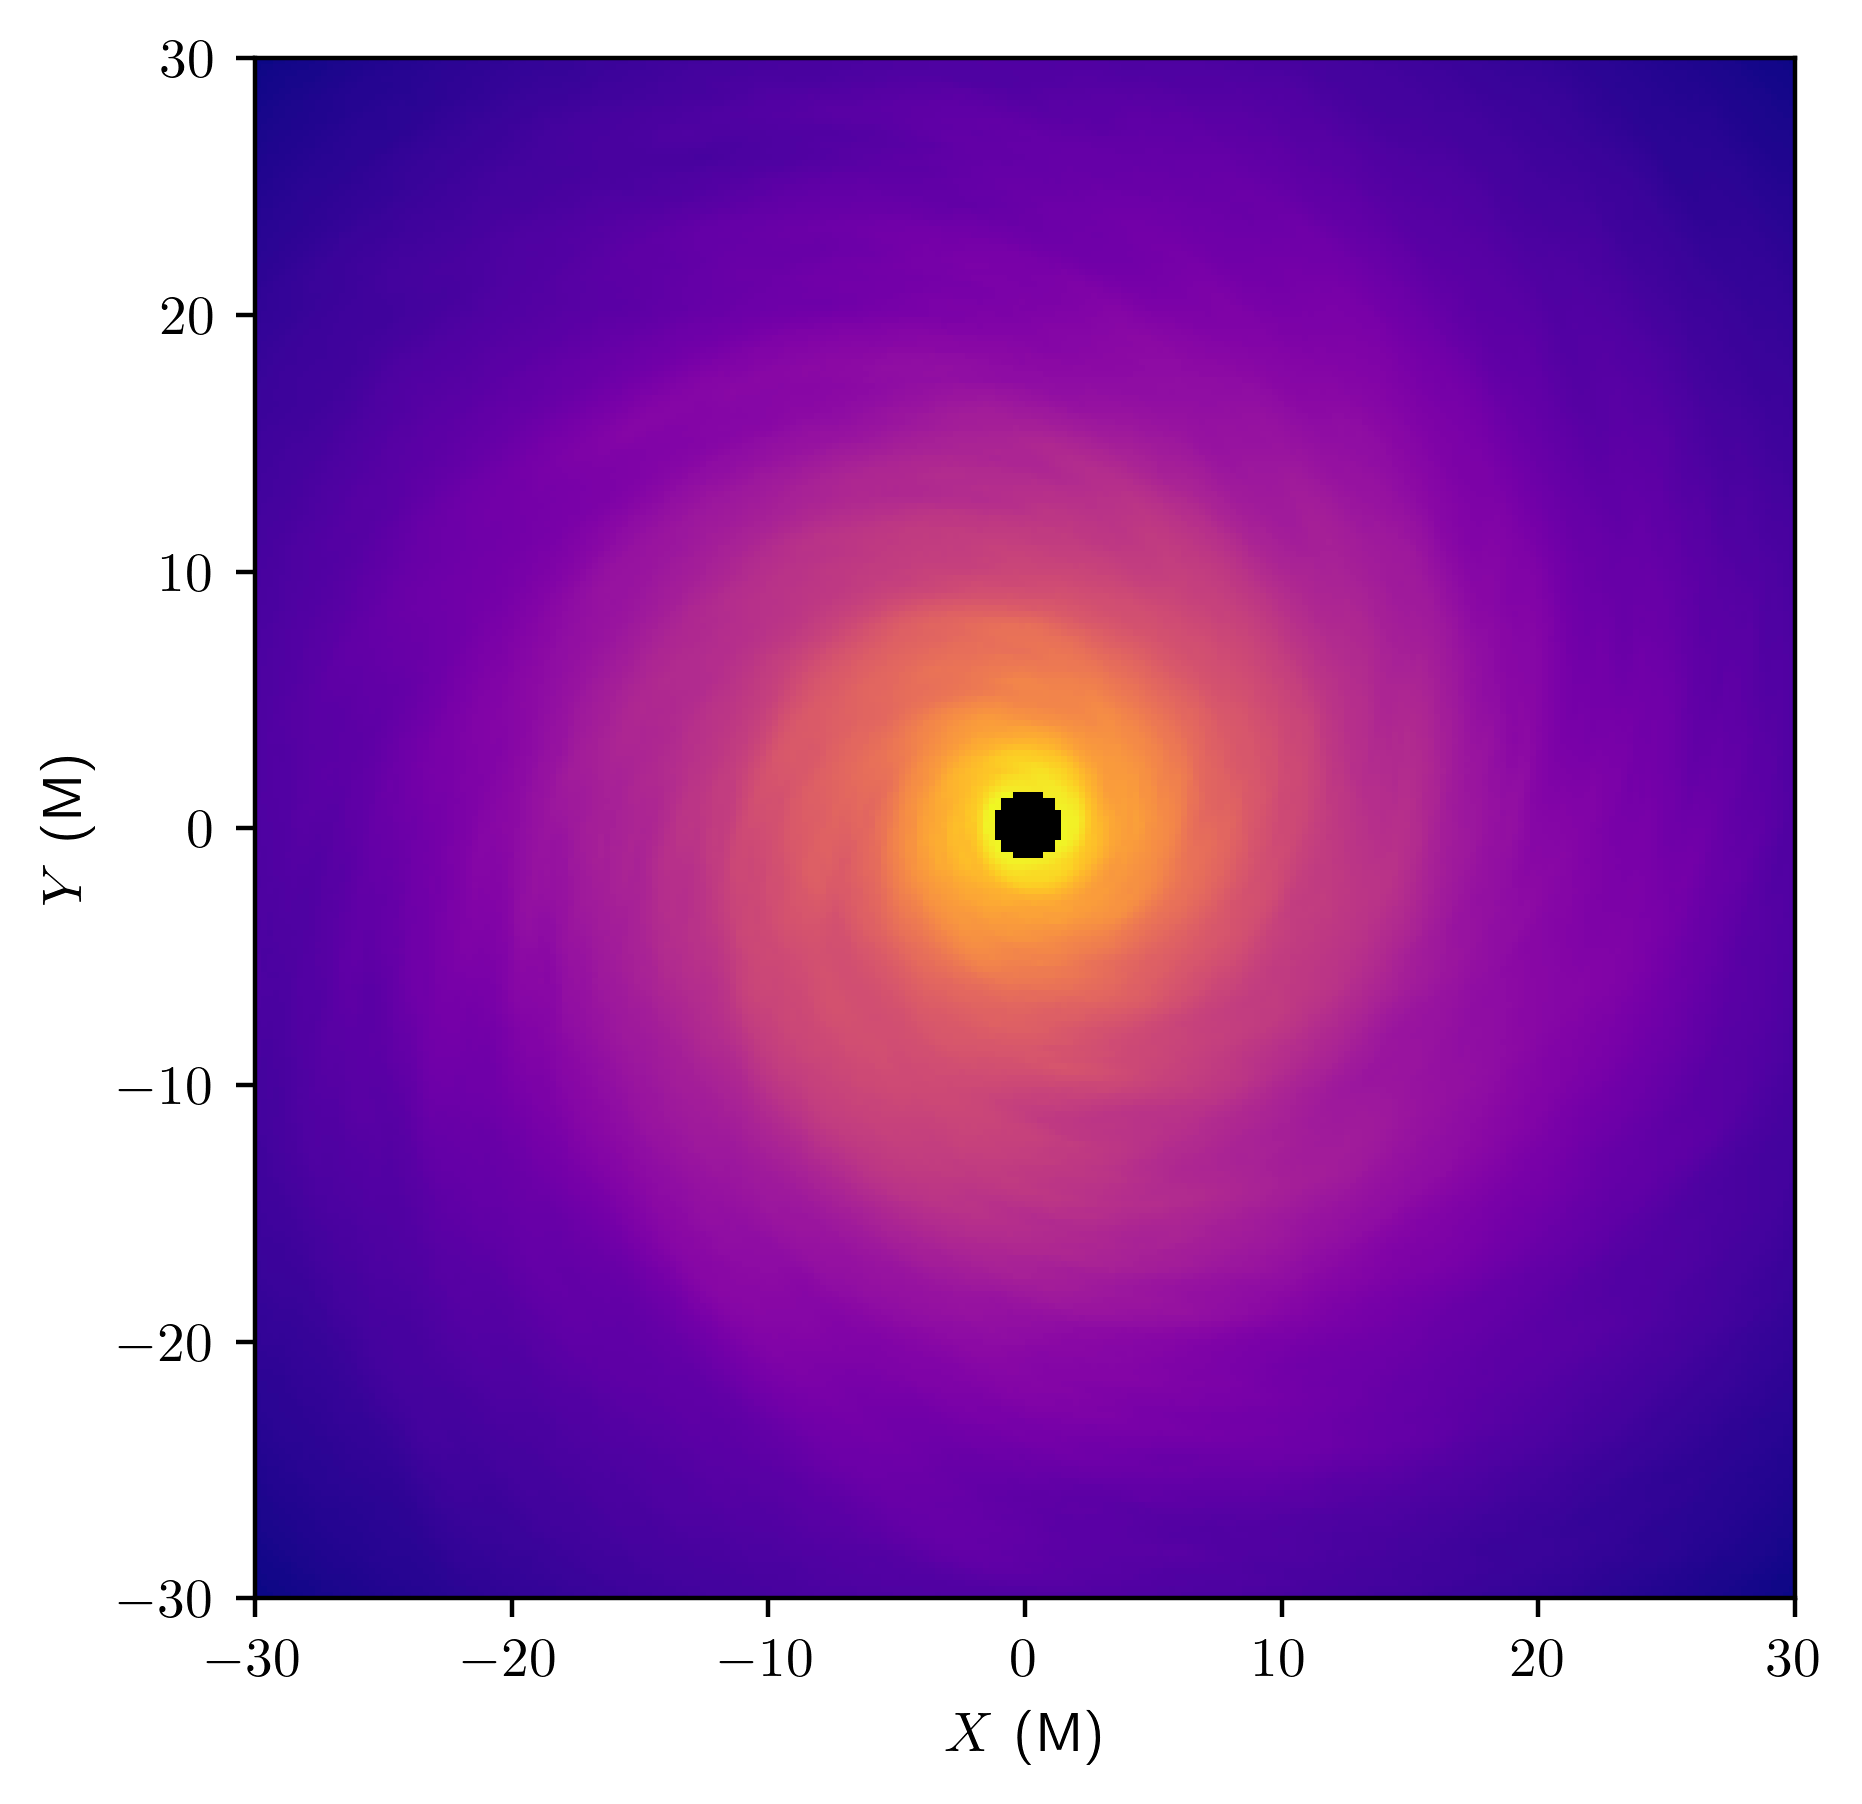

In [11]:
fig, ax = plt.subplots(figsize=[5,5],dpi=400)

#You can select different snapshots by changing the slicing 
ax.imshow(np.log(data[55,:,:]),cmap="plasma",origin="lower",extent=[-30,30,-30,30])

ax.set_facecolor('xkcd:black')
ax.set_xlabel(r"$X$"+" "+"(M)")
ax.set_ylabel(r"$Y$"+" "+"(M)")
#plt.savefig(f'InoisySnapshot.png',dpi=400,bbox_inches='tight')
plt.show()

In [19]:
nt =data.shape[0] #inoisy time resolution
ni = data.shape[1] #inoisy x resolution
nj = data.shape[2] #inoisy y resolution

try: 
	xtstart = np.array(hf['params/x0start'])[0]
	xtend = np.array(hf['params/x0end'])[0]

	x1start = np.array(hf['params/x1start'])[0]
	x2start = np.array(hf['params/x2start'])[0]

	x1end = np.array(hf['params/x1end'])[0]
	x2end = np.array(hf['params/x2end'])[0]

except:
	xtstart = np.array(hf['params/x0start'])
	xtend = np.array(hf['params/x0end'])

	x1start = np.array(hf['params/x1start'])
	x2start = np.array(hf['params/x2start'])

	x1end = np.array(hf['params/x1end'])
	x2end = np.array(hf['params/x2end'])


x1 = np.linspace(x1start, x1end, ni) 
x2 = np.linspace(x2start, x2end, nj)

times = np.linspace(xtstart, xtend, nt)

h5py.File.close(hf)

In [21]:
fact=-(D_obs+2*np.log(D_obs))

t0-=fact
t1-=fact
t2-=fact

i_dt = xtend/nt
timeconversion=i_dt*MMkg*Gc/cc**3/(3600*24) # [days]

interpolated3_R=RegularGridInterpolator((times,x1,x2),data,fill_value=0,bounds_error=False,method='linear')

In [23]:
p_b = 0.1
mode0, left0, right0, _, mass00, _ = obsint.modal_hdi_kde(t0, p_b)
mode1, left1, right1, _, mass01, _ = obsint.modal_hdi_kde(t1, p_b)
mode2, left2, right2, _, mass02, _ = obsint.modal_hdi_kde(t2, p_b)

In [18]:
print(mass00,mass01,mass02)
print(mode0 == right0,mode1 == right1,mode2 == right2)

0.10177047096606667 0.1183975690620776 0.10005234595544278
False False False


In [24]:
minV = 0
maxV = 99.95

t0_renorm_17 = t0 
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

minV = 5
maxV = 99.95

t1_renorm_17 = t1 
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = t2 
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

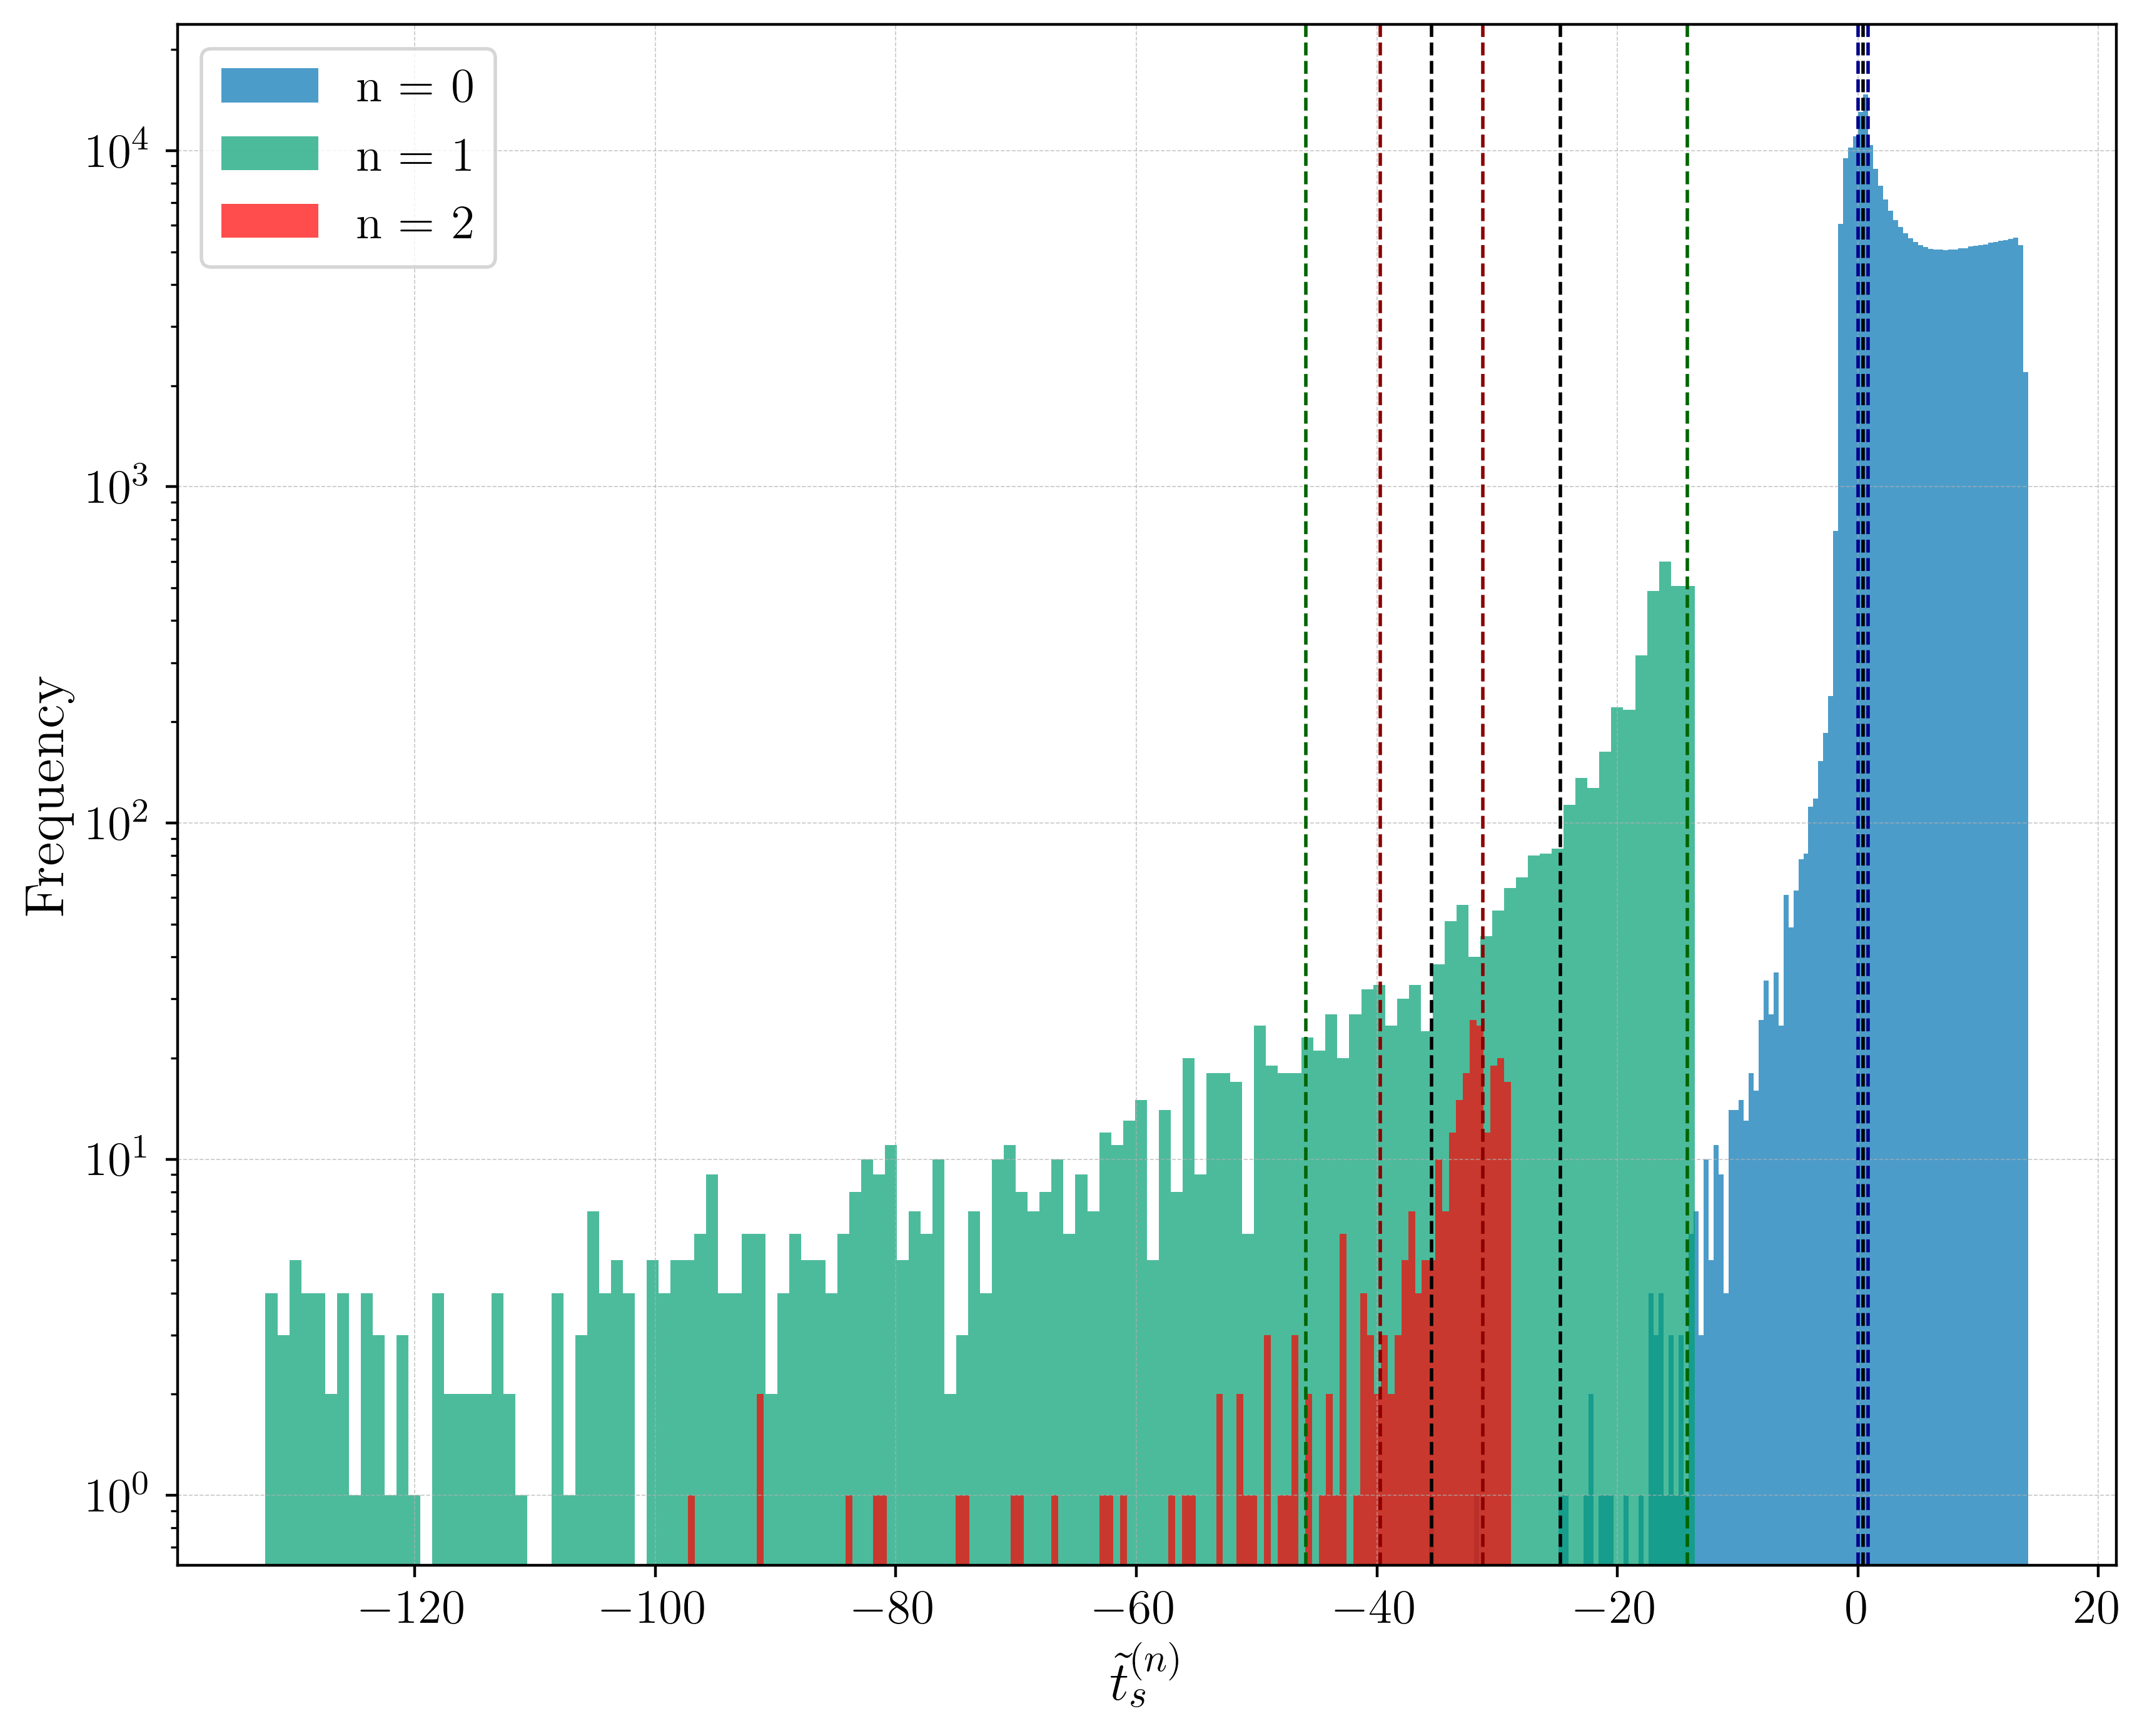

In [23]:
import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)
plt.axvline(x=mode0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left0, color='darkblue', linestyle='--', linewidth=1)
plt.axvline(x=right0, color='darkblue', linestyle='--', linewidth=1)


plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)
plt.axvline(x=mode1, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left1, color='darkgreen', linestyle='--', linewidth=1)
plt.axvline(x=right1, color='darkgreen', linestyle='--', linewidth=1)


plt.hist(t2_renorm_17, bins=120, color='red', label=r"n = 2", density=False, alpha=0.7)
plt.axvline(x=mode2, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left2, color='darkred', linestyle='--', linewidth=1)
plt.axvline(x=right2, color='darkred', linestyle='--', linewidth=1)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
#plt.xlim(-150,20)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

plt.show()

In [30]:
tsnap = 15
ts0 = np.mod(t0 + tsnap, xtend)
ts1 = np.mod(t1 + tsnap, xtend)
ts2 = np.mod(t2 + tsnap, xtend)

print(f"n = 0: Min = {np.nanmin(ts0)}, Max = {np.nanmax(ts0)} ")
print(f"n = 1: Min = {np.nanmin(ts1)}, Max = {np.nanmax(ts1)} ")
print(f"n = 2: Min = {np.nanmin(ts2)}, Max = {np.nanmax(ts2)} ")

mode0_snap = np.mod(mode0 + tsnap, xtend)
left0_snap = np.mod(left0 + tsnap, xtend)
right0_snap= np.mod(right0 + tsnap, xtend)

mode1_snap = np.mod(mode1 + tsnap, xtend)
left1_snap = np.mod(left1 + tsnap, xtend)
right1_snap= np.mod(right1 + tsnap, xtend)

mode2_snap = np.mod(mode2 + tsnap, xtend)
left2_snap = np.mod(left2 + tsnap, xtend)
right2_snap= np.mod(right2 + tsnap, xtend)

n = 0: Min = 0.1638579193786427, Max = 999.9676541332537 
n = 1: Min = 0.0021135477163625183, Max = 999.992551418738 
n = 2: Min = 274.9993543763376, Max = 986.1669004700598 


In [86]:
for ts in range(1000):
    tsnap = ts 
    ts0 = np.mod(t0 + tsnap, xtend)
    ts1 = np.mod(t1 + tsnap, xtend)
    ts2 = np.mod(t2 + tsnap, xtend)
    
    left0_snap = np.mod(left0 + tsnap, xtend)
    right0_snap= np.mod(right0 + tsnap, xtend)
    
    left1_snap = np.mod(left1 + tsnap, xtend)
    right1_snap= np.mod(right1 + tsnap, xtend)
    
    left2_snap = np.mod(left2 + tsnap, xtend)
    right2_snap= np.mod(right2 + tsnap, xtend)

    if right0_snap < left0_snap:
        print(0,tsnap)
    if right1_snap < left1_snap:
        print(1,tsnap)
    if right2_snap < left2_snap:
        print(2,tsnap)

1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
2 32
1 33
2 33
1 34
2 34
1 35
2 35
1 36
2 36
1 37
2 37
1 38
2 38
1 39
2 39
1 40
1 41
1 42
1 43
1 44
1 45


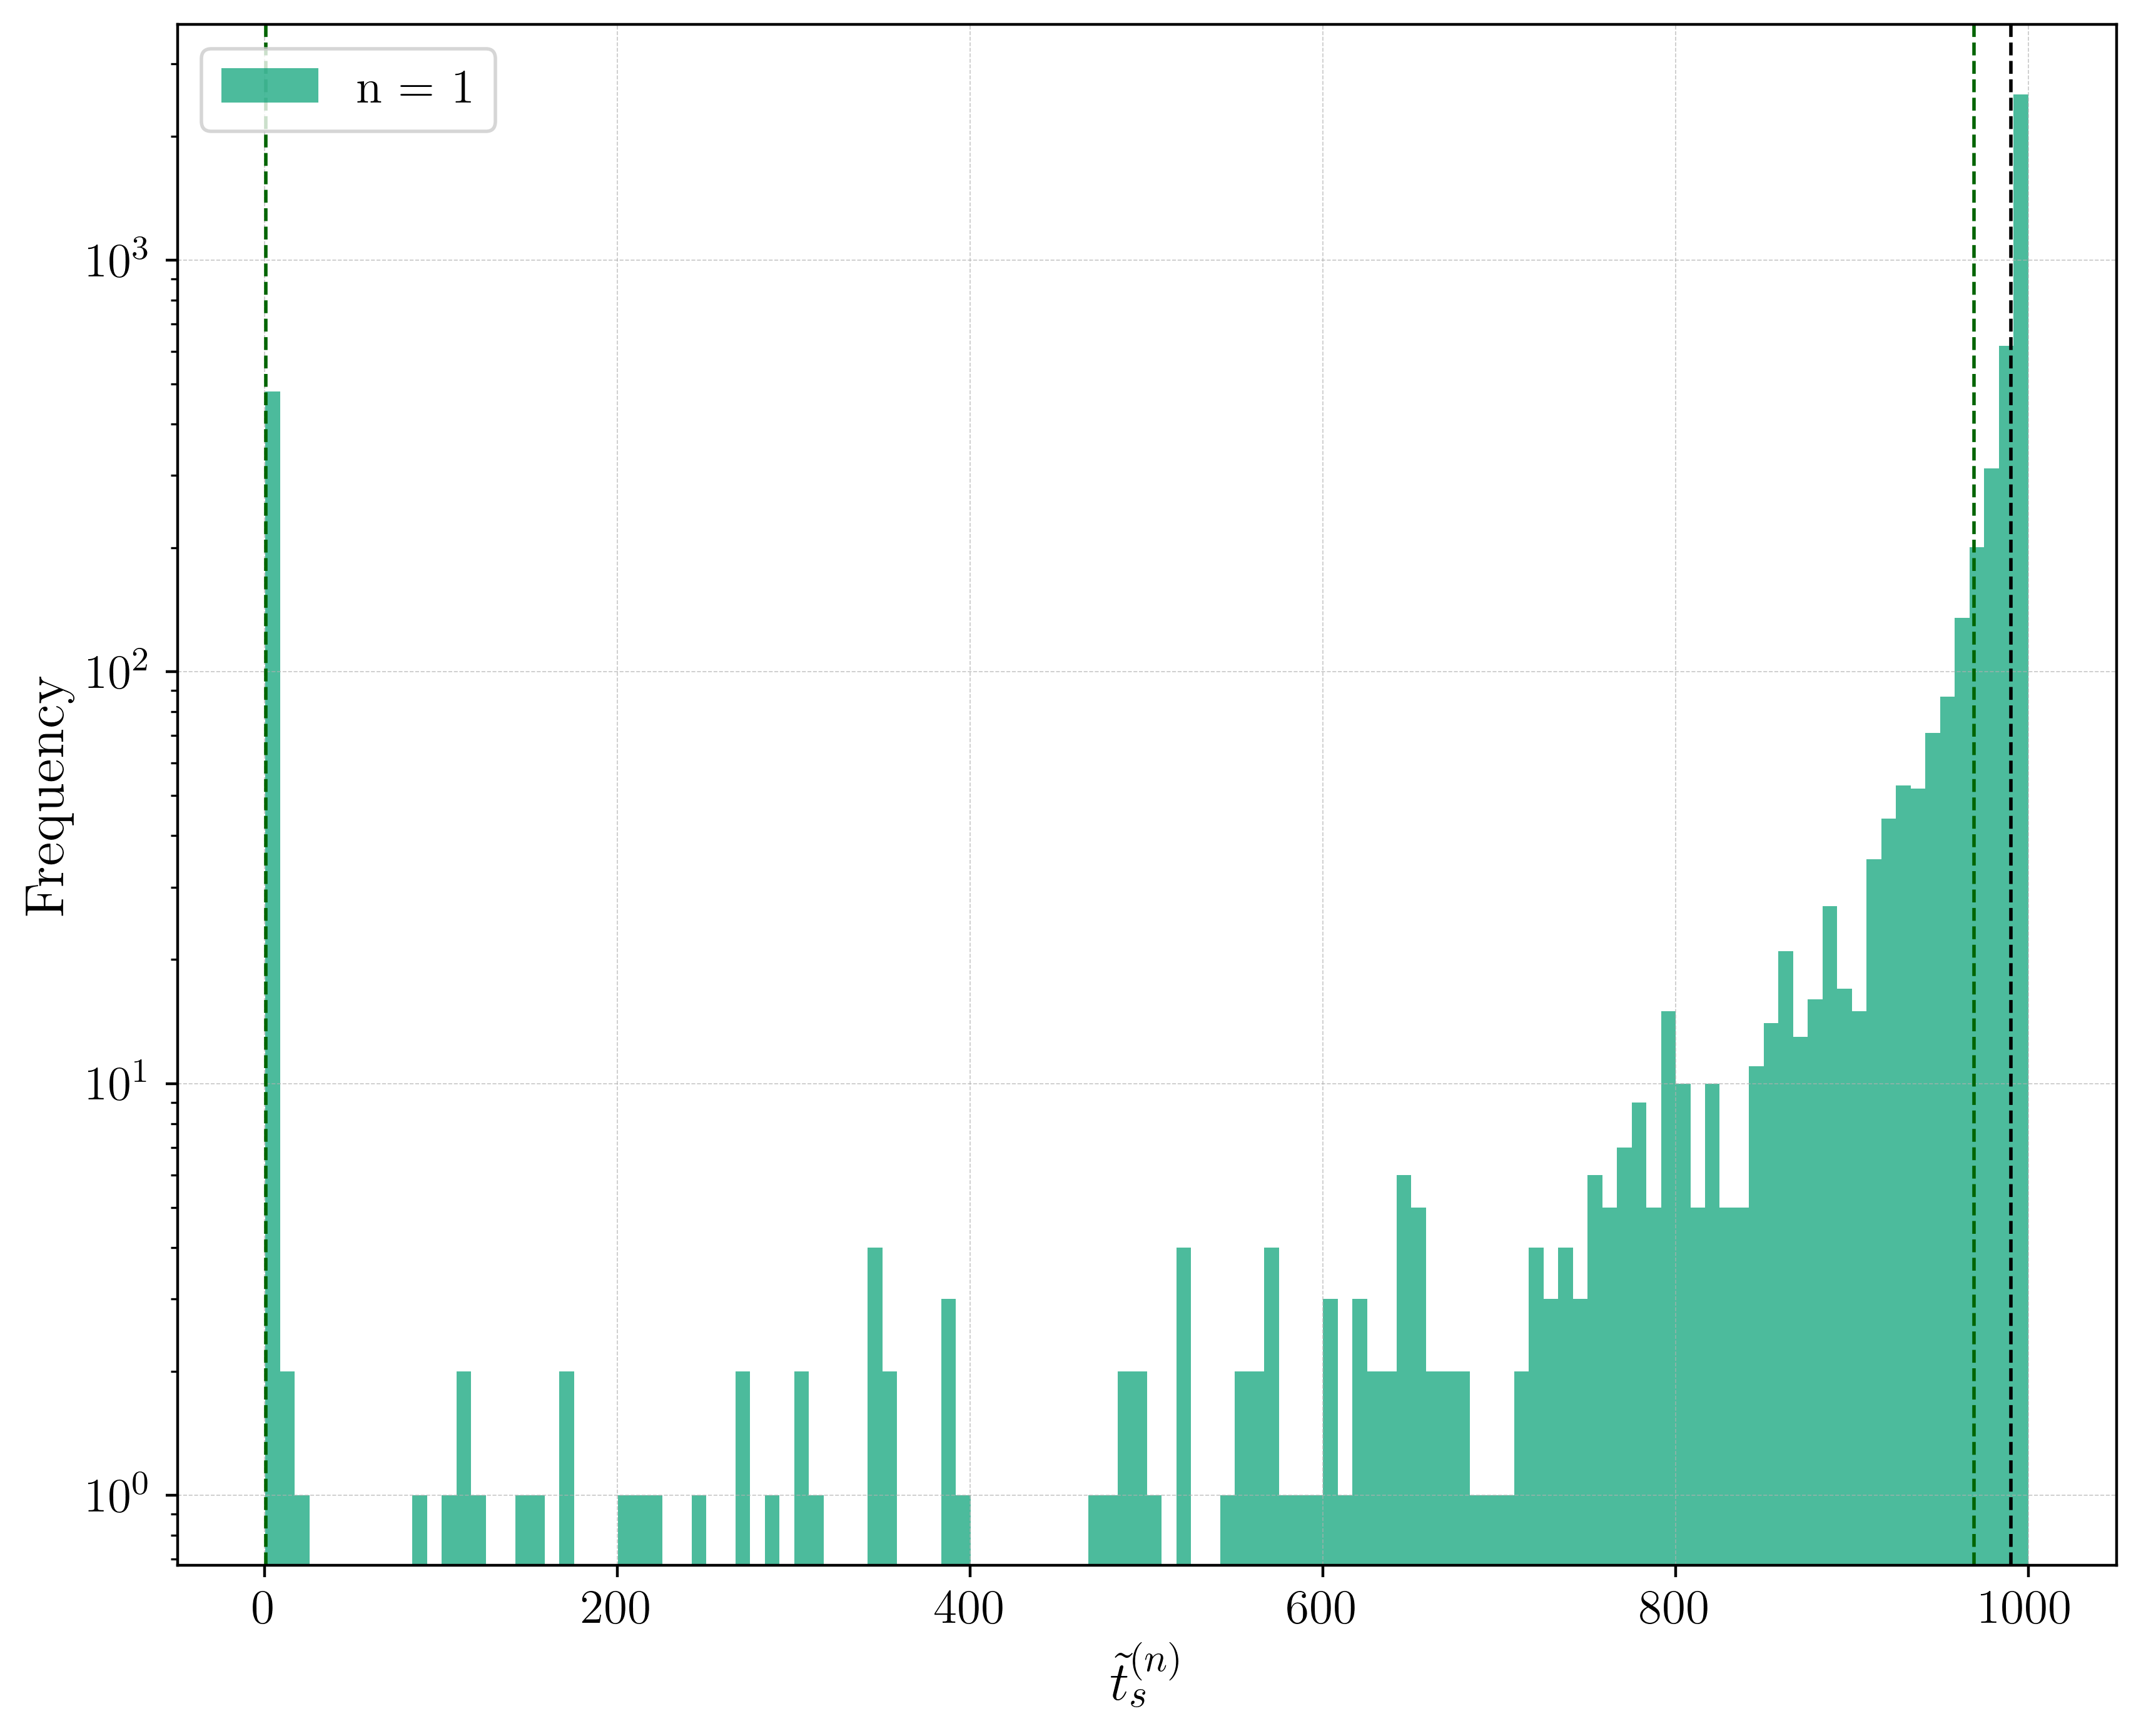

In [27]:
minV = 0
maxV = 99.95

t0_renorm_17 = ts0 
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

minV = 5
maxV = 99.95

t1_renorm_17 = ts1 
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = ts2 
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


#plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)
#plt.axvline(x=mode0_snap, color='black', linestyle='--', linewidth=1)
#plt.axvline(x=left0_snap, color='darkblue', linestyle='--', linewidth=1)
#plt.axvline(x=right0_snap, color='darkblue', linestyle='--', linewidth=1)


plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)
plt.axvline(x=mode1_snap, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left1_snap, color='darkgreen', linestyle='--', linewidth=1)
plt.axvline(x=right1_snap, color='darkgreen', linestyle='--', linewidth=1)


#plt.hist(t2_renorm_17, bins=120, color='red', label=r"n = 2", density=False, alpha=0.7)
#plt.axvline(x=mode2_snap, color='black', linestyle='--', linewidth=1)
#plt.axvline(x=left2_snap, color='darkred', linestyle='--', linewidth=1)
#plt.axvline(x=right2_snap, color='darkred', linestyle='--', linewidth=1)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
#plt.xlim(38,56)

plt.show()

In [33]:
shift_01 = int(np.round((mode1 - mode0)))
shift_02 = int(np.round((mode2 - mode0)))

k0 = tsnap
k1 = (k0 + shift_01) % (nt - 1)
k2 = (k0 + shift_02) % (nt - 1)

k0,k1,k2

(142, 117, 106)

In [40]:
dt_src = times[1] - times[0]

shift_01 = mode1 - mode0
shift_02 = mode2 - mode0

k0 = tsnap
k1 = (k0 + shift_01) 
k2 = (k0 + shift_02) 

## Si cogemos el tiempo de tsnap del frame de la fuente y hacemos raytracing, lo que tendremos es que correr  
print(f"tiempos de producción corridos: \n n=0: {k0}, n=1 {k1}, n=2 {k2}")
print(f"modas de la distribución en la fuente: \n n=0: {mode0_snap}, n=1 {mode1_snap}, n=2 {mode2_snap}")

tiempos de producción corridos: 
 n=0: 142, n=1 116.78522603465109, n=2 106.1058114693065
modas de la distribución en la fuente: 
 n=0: 142.45141974307325, n=1 117.23664577772433, n=2 106.55723121237975


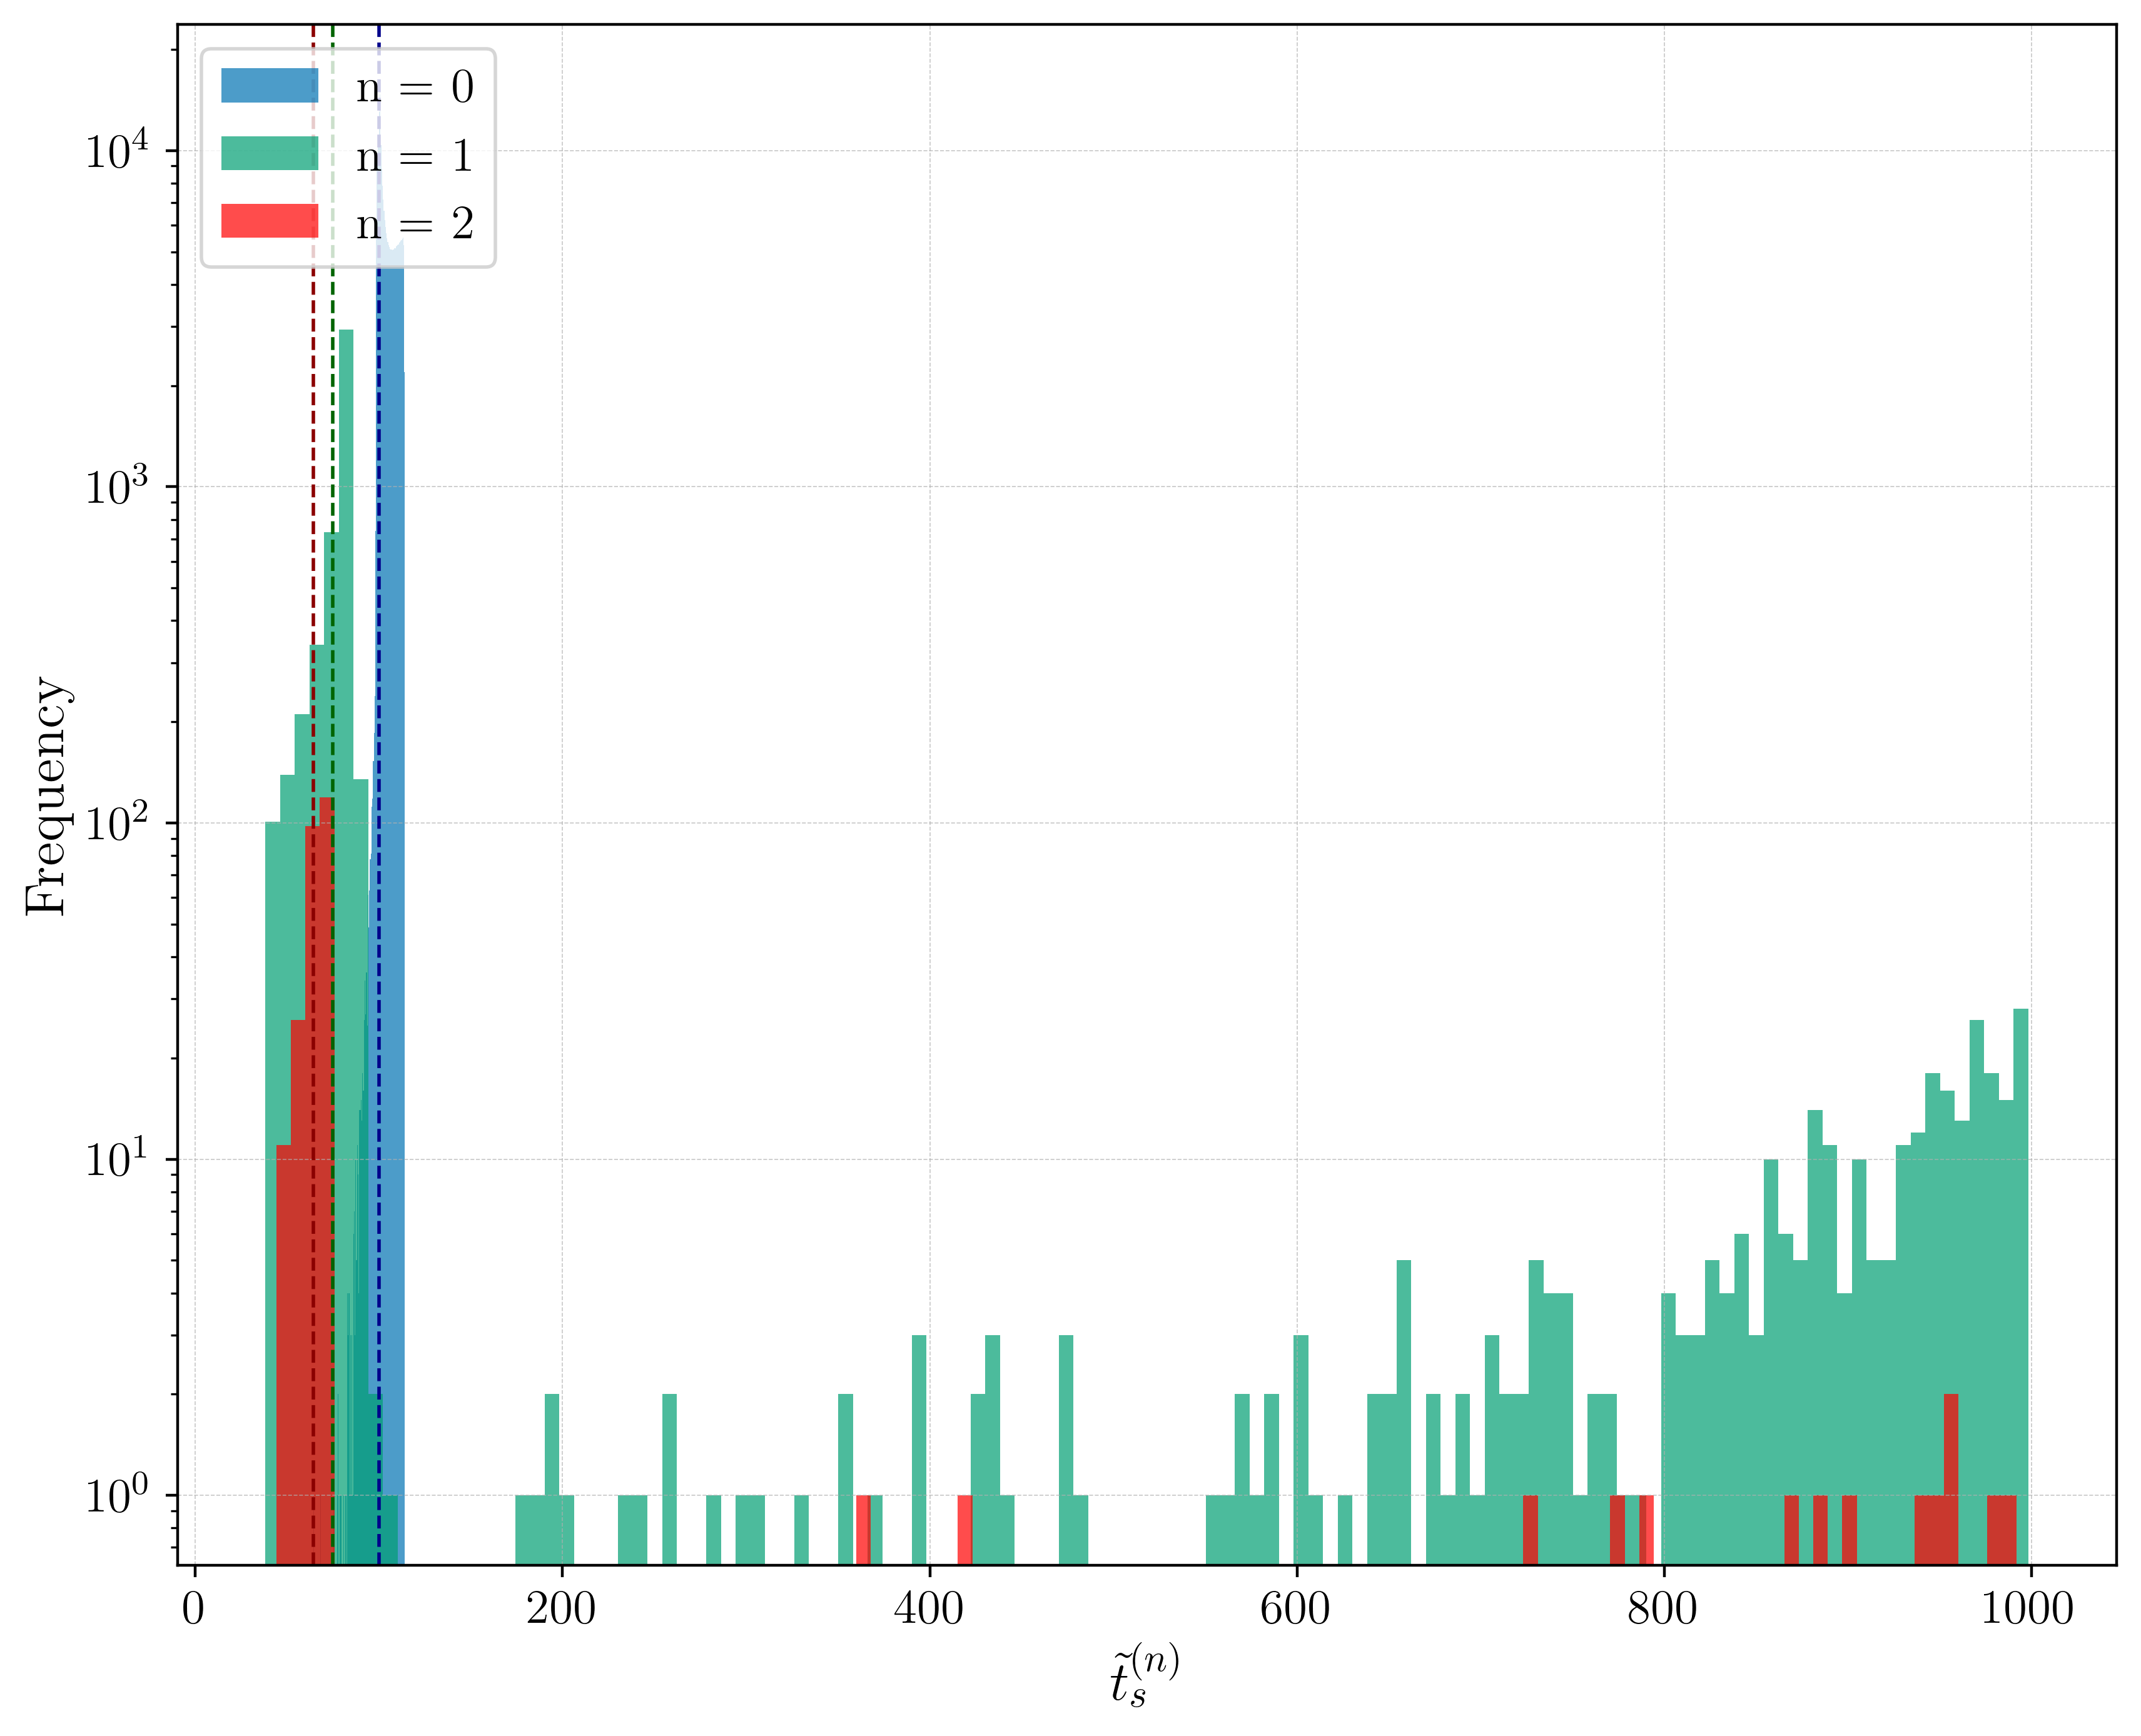

In [47]:
minV = 0
maxV = 99.95

t0_renorm_17 = ts0 
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

minV = 5
maxV = 99.95

t1_renorm_17 = ts1 
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = ts2 
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)


plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)


plt.hist(t2_renorm_17, bins=120, color='red', label=r"n = 2", density=False, alpha=0.7)



plt.axvline(x=k0, color='darkblue', linestyle='--', linewidth=1)
plt.axvline(x=k1, color='darkgreen', linestyle='--', linewidth=1)
plt.axvline(x=k2, color='darkred', linestyle='--', linewidth=1)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
#plt.xlim(38,56)

plt.show()

In [76]:
len(t2)

250000

In [40]:
import numpy as np

def clip_ts_to_interval(ts, left_s, right_s):
    """
    Clip finite values of a 1D time array to the interval [left_s, right_s].
    Non-finite values are preserved.
    :param ts array_like 1D: array of emission times. May contain NaN values.
    :param left_s: left boundary of the modal HDI
    :param right_s: right boundary of the modal HDI 

    Returns
    :param ts_out ndarray : Array with data in the range [left_s, right_s]
    """
    ts = np.asarray(ts, dtype=float)

    if ts.ndim != 1:
        raise ValueError("ts must be a 1D array.")
    if ts.size == 0:
        raise ValueError("ts cannot be empty.")
    if right_s < left_s:
        raise ValueError("right_s must be >= left_s.")

    ts_out = ts.copy()
    finite_mask = np.isfinite(ts_out)
    ts_out[finite_mask] = np.clip(ts_out[finite_mask], left_s, right_s)

    return ts_out

In [27]:
p_b = 0
mode0, left0, right0, _, mass00, _ = obsint.modal_hdi_kde(t0, p_b)
mode1, left1, right1, _, mass01, _ = obsint.modal_hdi_kde(t1, p_b)
mode2, left2, right2, _, mass02, _ = obsint.modal_hdi_kde(t2, p_b)


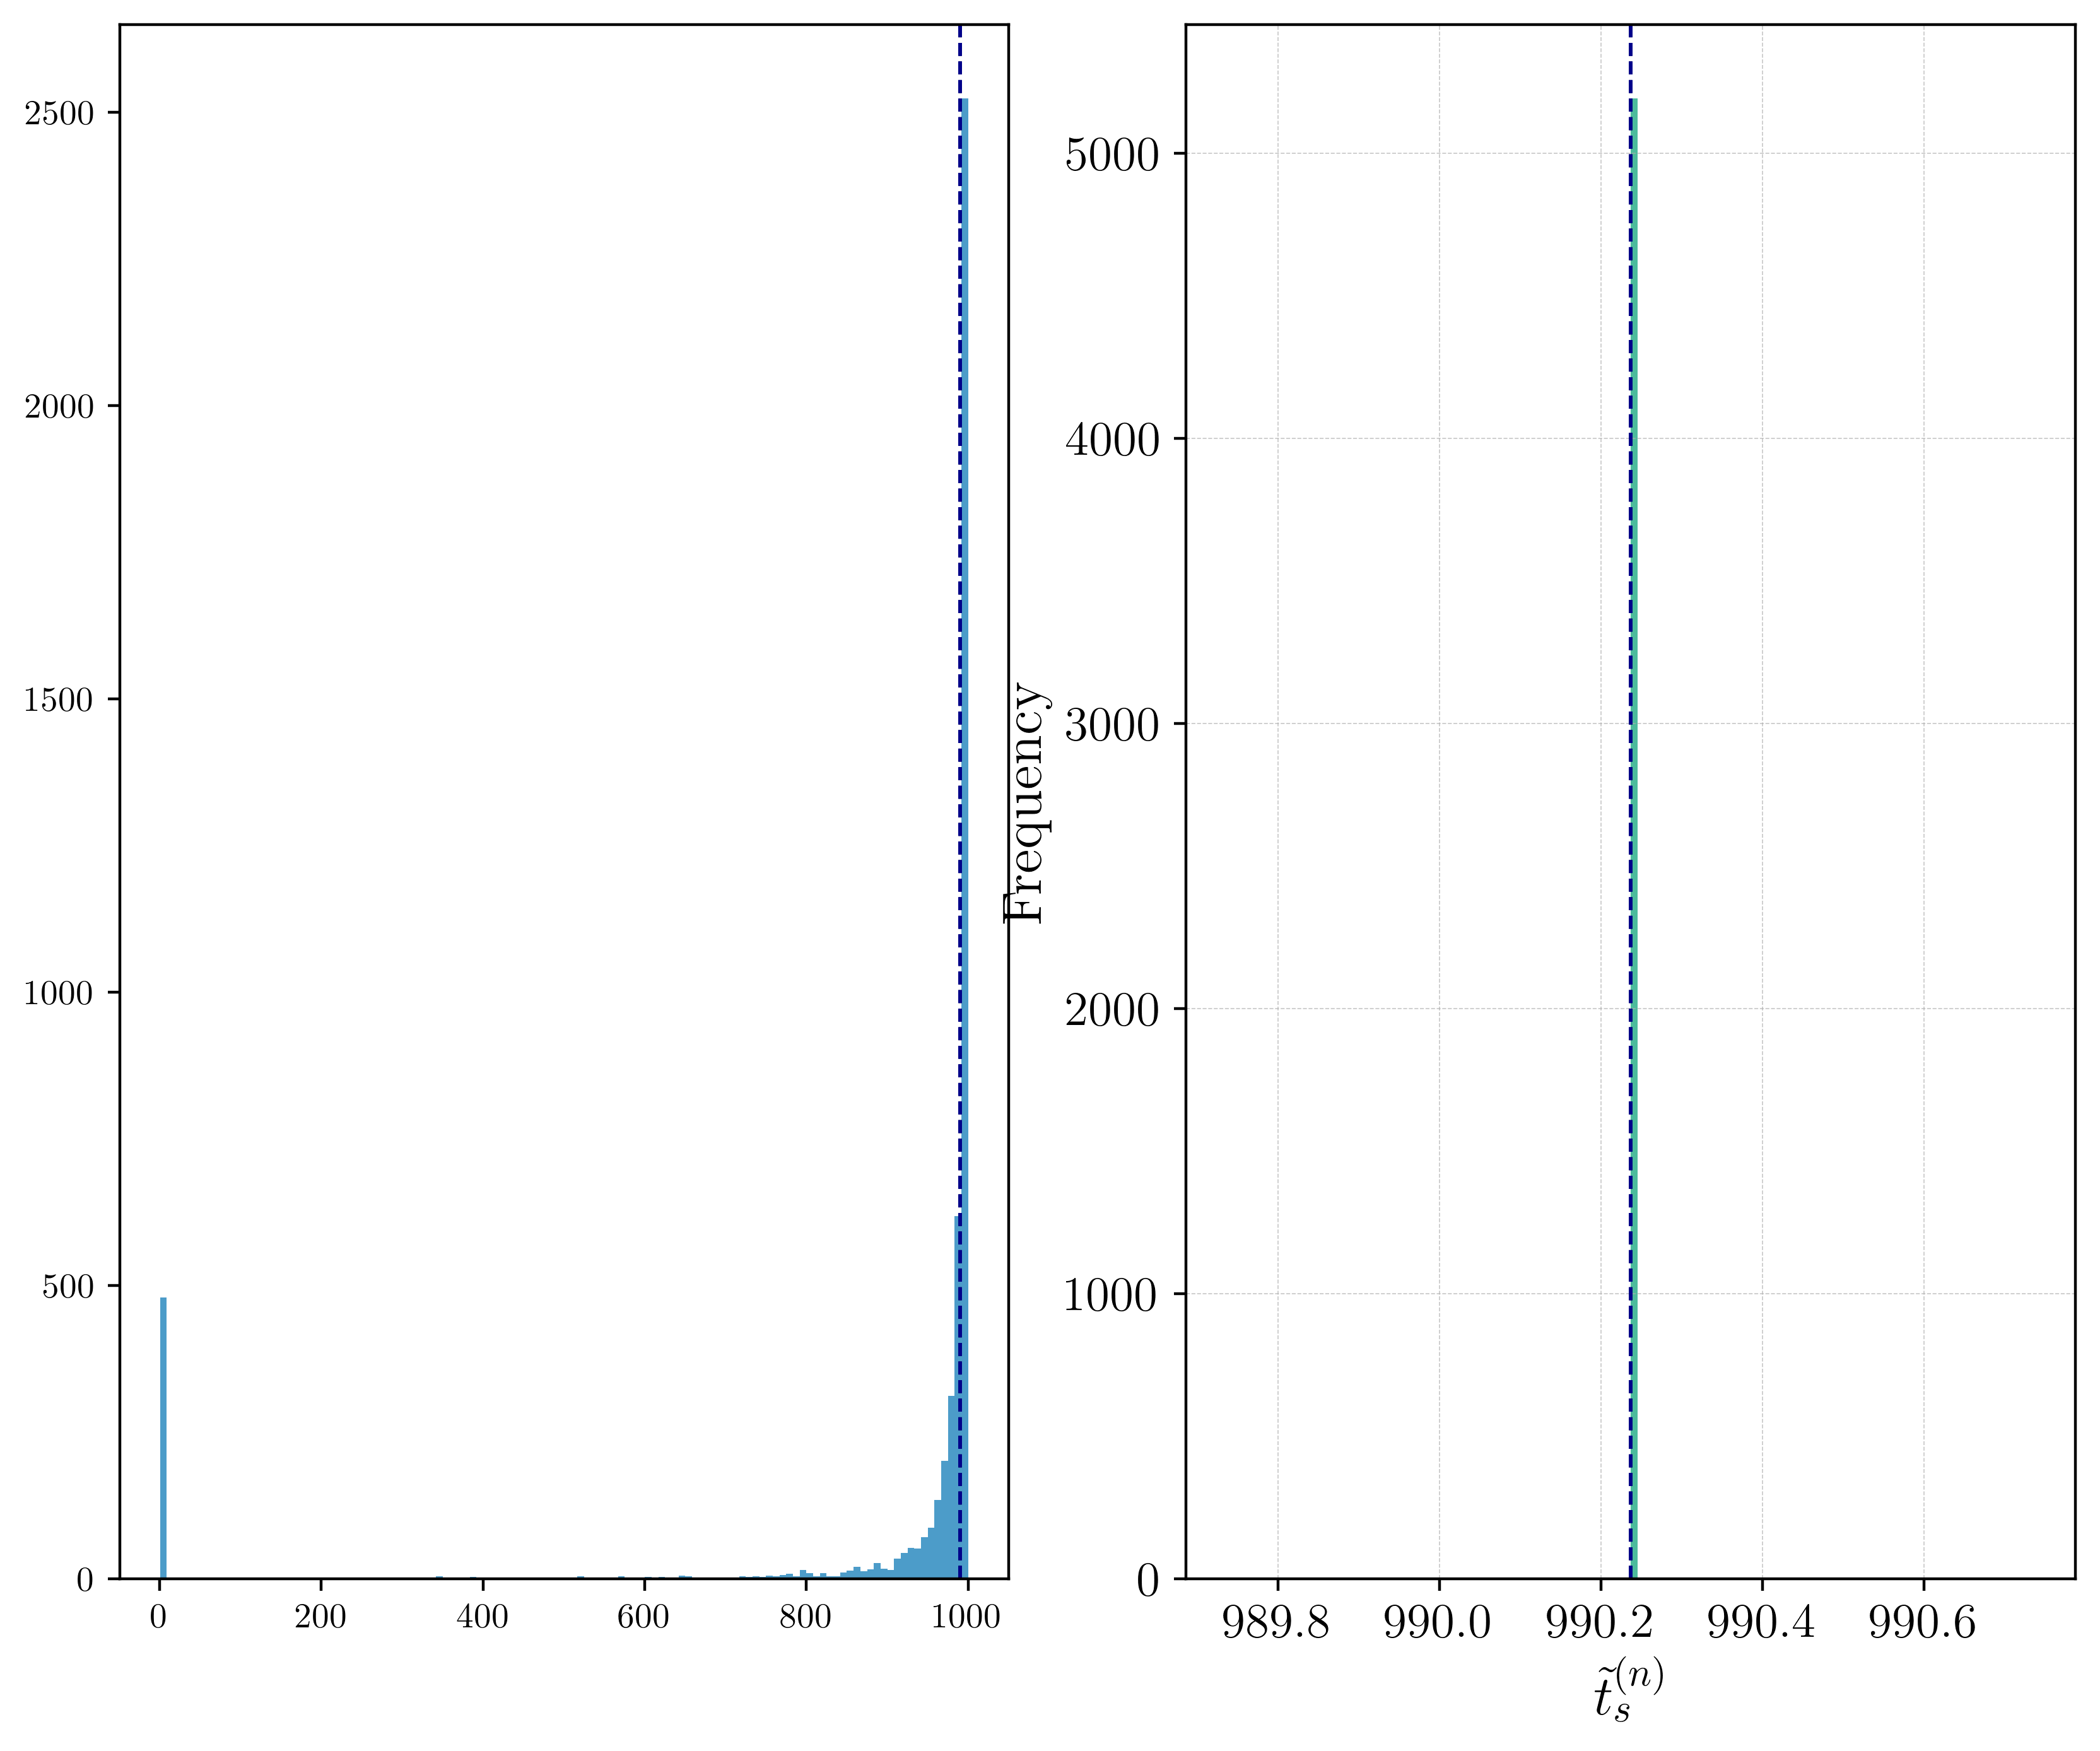

In [32]:

minV = 5
maxV = 99.95

t0_renorm_17 = ts1
valid_mask = np.isfinite(t0_renorm_17)
t0_renorm_17 = t0_renorm_17[valid_mask]
T0min17, T0max17 = np.percentile(t0_renorm_17, [minV,maxV])
mask_in_range_17 = (t0_renorm_17 >= T0min17) & (t0_renorm_17 <= T0max17 )
t0_renorm_17 = t0_renorm_17[mask_in_range_17]

mode  = mode1_snap
left  = left1_snap
right = right1_snap

ts_reduce = obsint.clip_ts_to_interval(ts1, left,right)
t1_renorm_17 = ts_reduce
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


plt.subplot(1,2,1)
plt.hist(t0_renorm_17, bins=120, color='#0072B2', label=r"n = 0", density=False, alpha=0.7)
plt.axvline(x=mode, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left, color='darkblue', linestyle='--', linewidth=1)
plt.axvline(x=right, color='darkblue', linestyle='--', linewidth=1)


plt.subplot(1,2,2)
plt.hist(t1_renorm_17, bins=120, color='#009E73', label=r"n = 1", density=False, alpha=0.7)
plt.axvline(x=mode, color='black', linestyle='--', linewidth=1)
plt.axvline(x=left, color='darkblue', linestyle='--', linewidth=1)
plt.axvline(x=right, color='darkblue', linestyle='--', linewidth=1)
#plt.ylim(0,2000)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

#plt.yscale("log")
#plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
#plt.xlim(38,56)

plt.show()

In [102]:
print(f"Antigua data range [{np.nanmin(t2)},{np.nanmax(t2)}]")
print(f"left value = {left}, right value = {right}")
print(f"Modificated data range [{np.nanmin(t1_renorm_17)},{np.nanmax(t1_renorm_17)}]")

Antigua data range [-11341.842872734658,-10047.253780273893]
left value = -10058.13943313762, right value = -10049.587465925526
Modificated data range [-10058.13943313762,-10049.587465925526]


In [104]:
np.sum(ts_reduce==t2), len(t1)

(146, 250000)